# Comparison between installed capacities in Denmark 2025
### This notebook aims to compare the installed electricities in Denmark 2025, using the powerplantmatching dataset, data from Energistyrelsen and the output of the network model generated from PyPSA-eur.


First load the data from the csv files and network file

In [1]:
import pandas as pd
import pypsa
from pathlib import Path

# The notebook is located in the "notebooks" directory
ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT_DIR / "data"
NET_DIR = DATA_DIR / "networks"

# Load powerplant data
df_ens = pd.read_csv(DATA_DIR / "powerplants.csv")
df_ppm = pd.read_csv(DATA_DIR / "powerplants_PPM.csv")

# Raw Energistyrelsen data
df_ens_pp = pd.read_csv(
        DATA_DIR / "ENS_power_plant_register.csv",
        sep=";",
        decimal=",",
    )

# Load network
ppm_network = pypsa.Network(NET_DIR / "base_s_3_elec_.nc")
ens_network = pypsa.Network(NET_DIR / "solved_2050.nc")


INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, sub_networks
INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, sub_networks


Lets compare the different technologies capacities installed with the ENS and PPM dataset 

Installed capacities per fueltype in Denmark active in 2025 [MW]:
                      ENS     PPM
Fueltype                         
Biogas          116.23600     0.0
Hard Coal       385.00000   716.0
Hydro             6.93900     0.0
Natural Gas    1780.21200  1461.2
Oil             732.61000   126.0
Solar          5068.32368  3364.9
Solid Biomass  1883.62800  1781.0
Waste           388.09000   153.0
Wind           7499.92134  4609.4


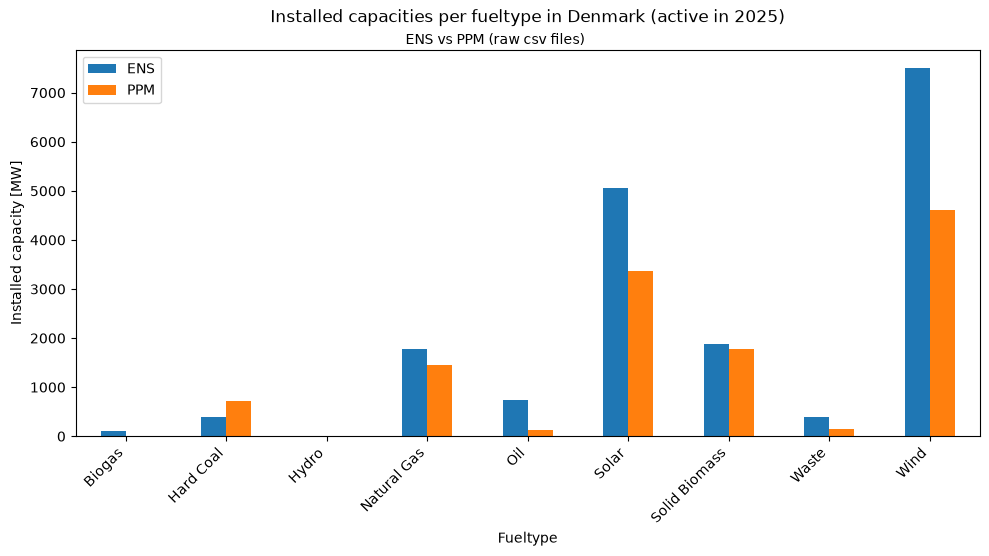

In [2]:
import matplotlib.pyplot as plt

YEAR = 2025


def active_in_year(df, year):
    is_dk = df["Country"] == "Denmark"
    is_in = df["DateIn"] <= year
    is_not_out = df["DateOut"].isna() | (df["DateOut"] >= year)
    return df.loc[is_dk & is_in & is_not_out]


df_ens_dk = active_in_year(df_ens, YEAR)
df_ppm_dk = active_in_year(df_ppm, YEAR)

cap_ens = df_ens_dk.groupby("Fueltype")["Capacity"].sum() # MW
cap_ppm = df_ppm_dk.groupby("Fueltype")["Capacity"].sum() # MW

comparison = pd.concat([cap_ens, cap_ppm], axis=1, keys=["ENS", "PPM"]).fillna(0)
print(f"Installed capacities per fueltype in Denmark active in {YEAR} [MW]:")
print(comparison)

comparison.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Installed capacity [MW]")
plt.title(f"Installed capacities per fueltype in Denmark (active in {YEAR})", y = 1.05)
plt.suptitle("ENS vs PPM (raw csv files)", fontsize=10, y=0.88)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Installed capacities per technology in Denmark active in 2025 [MW]:
                          ENS     PPM
Technology                           
CCGT                855.94000   711.2
Combustion Engine  1016.65600     0.0
OCGT                351.10000     0.0
Offshore           2598.50004  2652.6
Onshore            4879.76300  1956.8
PV                 5068.32368  3359.4
Run-Of-River          6.93900     0.0
Steam Turbine      3057.13000  1672.0
Csp                   0.00000     5.5


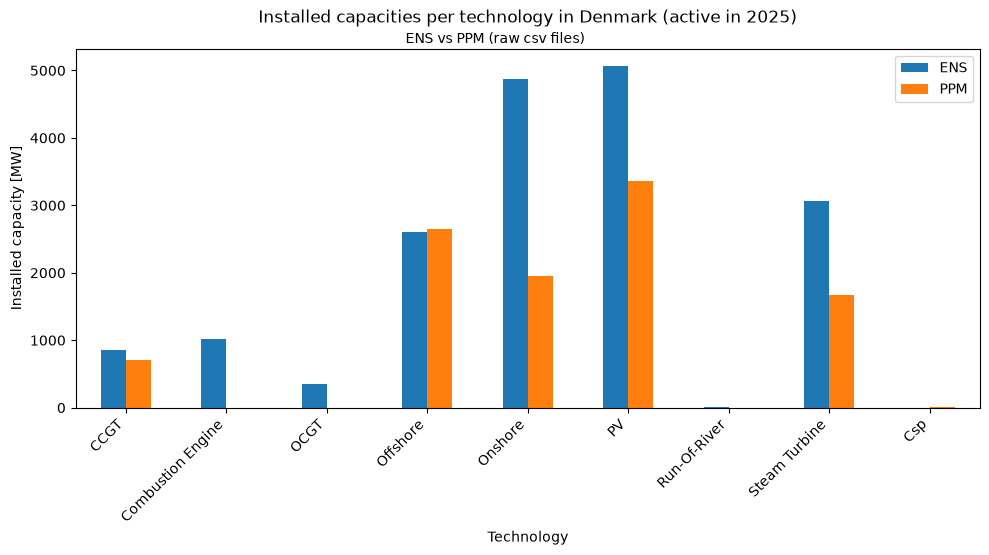

In [3]:
cap_ens = df_ens_dk.groupby("Technology")["Capacity"].sum() # MW
cap_ppm = df_ppm_dk.groupby("Technology")["Capacity"].sum() # MW

comparison = pd.concat([cap_ens, cap_ppm], axis=1, keys=["ENS", "PPM"]).fillna(0)
print(f"Installed capacities per technology in Denmark active in {YEAR} [MW]:")
print(comparison)

comparison.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Installed capacity [MW]")
plt.title(f"Installed capacities per technology in Denmark (active in {YEAR})", y = 1.05)
plt.suptitle("ENS vs PPM (raw csv files)", fontsize=10, y=0.88)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [9]:
# Check total heat capacity of installed heat from df_ens_pp

total_heat_capacity = df_ens_pp["varmekapacitet_MW"].sum()
print(f'Total installed heat capacity from Energistyrelsen data: {total_heat_capacity} MW')

# check how much of it is from combined heat and power (CHP) plants
chp_heat_capacity = df_ens_pp[df_ens_pp["elkapacitet_MW"] > 0]["varmekapacitet_MW"].sum()
print(f'Total installed heat capacity from CHP plants: {chp_heat_capacity} MW')

Total installed heat capacity from Energistyrelsen data: 26507.5246 MW
Total installed heat capacity from CHP plants: 9507.455600000001 MW


### Comparing different network files
Now we can look further into the generated network files with different input data and config files from PyPSA-Eur

Installed capacities per carrier in Denmark [MW]:
               PPM network  ENS network
carrier                                
CCGT            1629.83000   1629.83000
OCGT            1049.60200   1049.60200
biomass         1445.15000   1445.15000
coal             385.00000    385.00000
offwind-ac      2565.40004   2574.90004
offwind-dc         0.00000      0.00000
offwind-float      0.00000      0.00000
oil              450.68800    450.68800
onwind          4147.76100   4529.40800
ror                6.63400      6.63400
solar           4987.67749   4987.61719
solar-hsat         0.00000      0.00000
waste            293.20000    293.20000


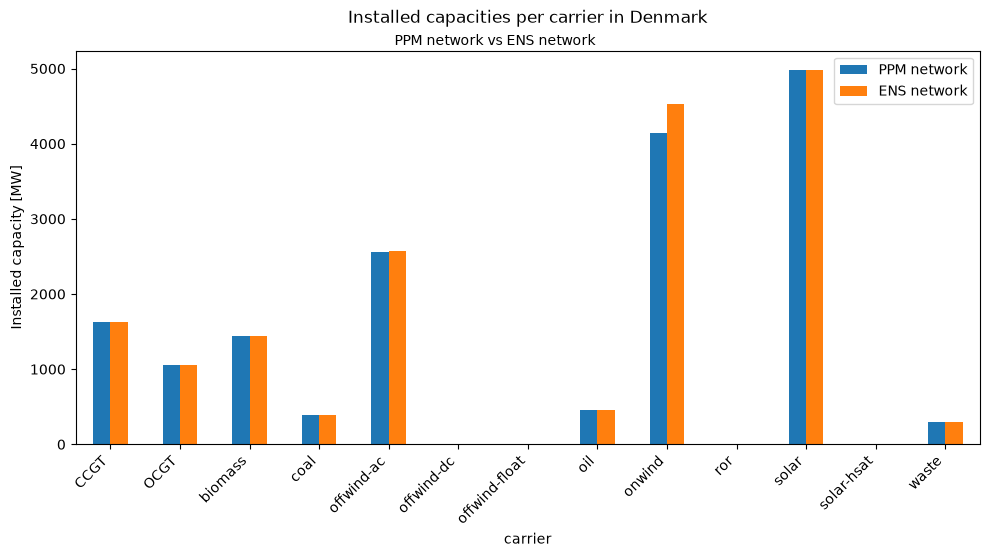

In [5]:
def dk_capacity_by_carrier(network):
    dk_buses = network.buses.index[network.buses["country"] == "DK"]

    gens = network.generators.loc[network.generators["bus"].isin(dk_buses), ["carrier", "p_nom"]]
    storage = network.storage_units.loc[network.storage_units["bus"].isin(dk_buses), ["carrier", "p_nom"]]

    components = pd.concat([gens, storage])
    return components.groupby("carrier")["p_nom"].sum()


cap_ppm_net = dk_capacity_by_carrier(ppm_network)
cap_ens_net = dk_capacity_by_carrier(ens_network)

network_comparison = pd.concat(
    [cap_ppm_net, cap_ens_net], axis=1, keys=["PPM network", "ENS network"]
).fillna(0)
print("Installed capacities per carrier in Denmark [MW]:")
print(network_comparison)

network_comparison.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Installed capacity [MW]")
plt.title("Installed capacities per carrier in Denmark", y=1.05)
plt.suptitle("PPM network vs ENS network", fontsize=10, y=0.88)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()